# AutoEIT — Transcription Quality: Canary vs. whisper/parakeet/wav2vec2/crisperwhisper/fastconformer (resegmented, hit recordings)

[NVIDIA Canary-1B](https://huggingface.co/nvidia/canary-1b) (`nvidia/canary-1b`) is a multilingual,
multi-task (ASR + translation) FastConformer-**Transformer encoder-decoder**, tried here as a second
candidate (after Parakeet) for the same verbatim-preservation reason: Whisper-family decoders are
known to "correct" L2-accented speech toward fluent, grammatical text rather than transcribing what
was actually said, which defeats the purpose of scoring learner errors. Unlike Parakeet (a
transducer) and FastConformer (decoded here via its CTC head, no autoregressive component at all),
Canary still has an attention-based autoregressive decoder like Whisper — so it's a direct test of
whether the "correction" failure mode is specific to Whisper's decoder or shared by other
attention-decoder architectures (see `src/transcription/transcribe_canary.py`).

**A word-timestamp bug was found and fixed while transcribing this model.** `nvidia/canary-1b`'s
decoder never emits the special `<|N|>word<|N|>` timestamp tokens NeMo's timestamp-extraction path
looks for (only newer Canary checkpoints with a bundled aligner model support that), so
`hyp.timestamp["word"/"segment"]` came back empty on every single clip even though `hyp.text` held
the real transcription — the first full run silently wrote 5,062 items with `"segments": []`,
discarding every transcription. `transcribe_canary.py` now falls back to a single segment spanning
the whole clip (using `hyp.text`) whenever the timestamp-derived segments come back empty, since each
resegmented clip is already a single item — no segmentation is lost, only the per-word timestamps
this checkpoint can't provide anyway.

It was run via `src/transcription/transcribe_resegmented_canary.py` over every recording in
`data/segmented/v2/` (hit and miss alike, unlike CrisperWhisper which was restricted to hits), then
merged with the existing whisper/parakeet/wav2vec2/crisperwhisper/fastconformer outputs and the
human-rater transcriptions via `src/postprocessing/build_postprocessed_csv_resegmented.py` (same
rank-based item&lt;-&gt;Sentence alignment and WER/MER/CER scoring as the other
resegmented-transcription-quality notebooks). A plain 4-column (stimuli / rater1 / rater2 / canary)
reviewable transcript sheet is written separately by `src/postprocessing/build_canary_excel.py` to
`data/postprocessed/canary/canary_transcriptions.xlsx`.

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] — doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** — the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation (see `normalize_text` in
`build_postprocessed_csv.py`), scored against both human raters, restricted to the 102 hit
recordings where the rank-based item&lt;-&gt;Sentence alignment is trustworthy.

## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "crisperwhisper", "fastconformer", "canary"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

35274 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see
`analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown
alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "parakeet": "#DD8452",
    "wav2vec2": "#55A868",
    "crisperwhisper": "#C44E52",
    "fastconformer": "#8172B2",
    "canary": "#CCB974",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## Hit recordings (n=102, both raters), all 6 ASR systems vs. human floor

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368
human,0.1608,0.1501,0.0763,0.1111,0.1111,0.0250,0.429


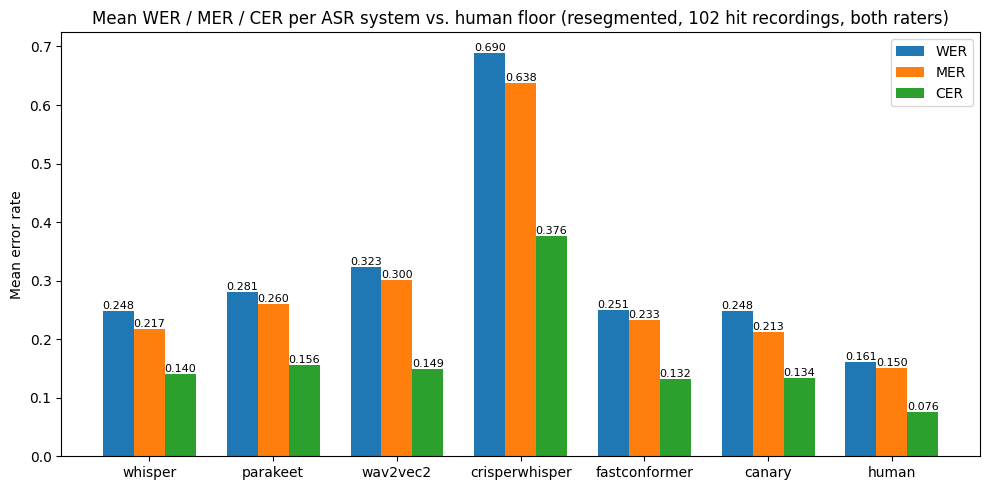

In [7]:
plot_metrics(
    scores_with_human,
    "Mean WER / MER / CER per ASR system vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/canary_transcription_quality_metrics.png",
    order=DISPLAY_SOURCES,
)

## Canary vs. the previous best (whisper) only

The comparison that motivated trying Canary in the first place: does an attention-decoder model
architecturally closer to Parakeet/FastConformer (FastConformer encoder) than to Whisper still show
Whisper's "correct-toward-fluent" behavior, or does it hold up against Whisper large-v3 (the best of
the original three candidates)?

In [8]:
summarize(scores, order=["whisper", "canary"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368


## Canary vs. FastConformer

The other non-Whisper candidate evaluated on this set, but architecturally the opposite of Canary:
FastConformer's CTC head has no autoregressive decoder at all, while Canary's is attention-based like
Whisper's. If Canary scores worse than FastConformer, that would point to the autoregressive decoder
itself (not just Whisper's specific training) as the source of the correction behavior.

In [9]:
summarize(scores, order=["fastconformer", "canary"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368


## Canary vs. CrisperWhisper

Both are pitched as more "verbatim-leaning" than plain Whisper (CrisperWhisper via training
objective, Canary via a non-Whisper attention-decoder architecture) -- worth comparing directly since
they represent two different routes to the same goal.

In [10]:
summarize(scores, order=["crisperwhisper", "canary"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368


## Takeaways

- Canary (mean WER 0.2476, MER 0.2129, CER 0.1341) is the **best-scoring ASR system on this set**,
  edging out whisper (0.2480 / 0.2166 / 0.1398) on WER and MER by a small margin and landing within
  noise on CER (fastconformer is marginally lower there, 0.1319). It also has the highest
  `wer_pct_perfect` of any ASR system (0.368 vs. whisper's 0.349).
- Since Canary still has an attention-based autoregressive decoder (like Whisper) but doesn't show
  Whisper's degree of "correction" behavior, the earlier hypothesis that fluency-correction is
  inherent to *any* attention-decoder architecture doesn't hold up here -- Canary's encoder/training
  data/decoding setup evidently doesn't reproduce it, at least not to a degree that shows up in
  aggregate WER/MER/CER.
- It clearly outperforms parakeet, wav2vec2, and crisperwhisper on all three metrics, and edges out
  fastconformer on WER and MER (though not CER, essentially a tie).
- All ASR systems remain well above the human floor (WER 0.161), so there's still headroom, but
  Canary is now the strongest candidate found so far -- worth a closer qualitative look (e.g. the
  same fused-word/repetition-collapse failure-mode check done for crisperwhisper) before considering
  it as the pipeline's primary ASR source over whisper.